# Clustering avec k=3

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../DATA/Data_concat/donnees_compilees.csv')
data.head(10)

,entity,annee,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,...,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2,ranking
0,A N Gratchev,2023-01-01,2,0.2,0,0.0,0,0.0,2,0.2,...,0,0.0,0,0,0,0,0,0,0.000000,8735
1,A N Gratchev,2024-01-01,1,0.1,0,0.0,0,0.0,1,0.1,...,0,0.0,0,0,0,0,3,3,0.076447,8223
2,A N Gratchev,2025-01-01,1,0.1,0,0.0,0,0.0,1,0.1,...,0,0.0,0,0,0,0,3,6,0.129972,5888
3,Aadel A Chaudhuri,2023-01-01,2,6.9,0,0.0,0,0.0,2,6.9,...,0,0.0,0,0,0,0,0,0,0.000000,1935
4,Aadel A Chaudhuri,2024-01-01,3,0.3,1,0.1,0,0.0,2,0.2,...,0,0.0,1,0,0,1,53,67,4.834006,2155
5,Aadel A Chaudhuri,2025-01-01,2,29.8,1,29.7,0,0.0,1,0.1,...,0,0.0,0,0,0,0,7,14,1.064320,2307
6,Aakash Desai,2023-01-01,5,20.1,1,4.0,4,16.1,0,0.0,...,0,0.0,0,0,0,0,3,3,0.745592,285
7,Aakash Desai,2024-01-01,7,22.2,3,8.0,3,14.1,1,0.1,...,0,0.0,3,0,2,1,110,112,9.115923,300
8,Aakash Desai,2025-01-01,12,83.3,8,54.5,2,13.8,2,15.0,...,0,0.0,3,2,1,1,354,366,29.269657,309
9,Aaron Allen,2023-01-01,2,8.7,2,8.7,0,0.0,0,0.0,...,0,0.0,0,0,0,0,3,3,0.686332,9893


In [3]:
data.describe()

,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,guid_count_publications,guid_sum_Impact_factor,...,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2,ranking
count,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,...,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000,39122.000000
mean,2.307960,15.377164,1.774935,12.793104,0.219365,1.156393,0.313992,1.427667,0.000792,0.042316,...,0.000102,0.005797,0.086575,0.014544,0.036348,0.060324,18.894816,23.740172,2.510613,6820.395123
std,2.901269,38.446894,2.314995,32.514069,0.584458,6.759841,0.882894,8.125966,0.037487,2.063952,...,0.012384,0.702165,0.504771,0.185263,0.240901,0.506587,47.882178,58.355389,6.043385,3937.330934
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3402.000000
50%,2.000000,4.500000,1.000000,3.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,7.000000,0.606195,6821.000000
75%,3.000000,12.000000,2.000000,9.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,22.000000,2.180632,10436.000000
max,52.000000,923.200000,36.000000,786.600000,13.000000,260.600000,20.000000,472.200000,2.000000,113.400000,...,2.000000,113.400000,17.000000,8.000000,7.000000,19.000000,931.000000,1288.000000,100.000000,13045.000000


## Préparation des données

1. Concaténation entity + annee
2. Supprimer les colonnes ranking, entity, et annee de la matrice X
3. Scaling des données avec StandardScaler

In [4]:
# 1. Concaténation entity + annee
data['annee'] = pd.to_datetime(data['annee'])
data["entity_annee"] = (
    data["entity"].astype(str)
    + "_" 
    + data["annee"].dt.year.astype(str)
)

In [22]:
2. Supprimer les colonnes ranking, entity, et annee de la matrice X
data_X = data.drop(columns=['ranking','entity','annee'])
data.sort_values(by='ranking').head(20)

,entity,annee,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,...,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2,ranking,entity_annee
20328,Martin Reck,2023-01-01,38,682.2,29,517.3,4,54.0,5,110.9,...,0.0,0,0,0,0,255,402,100.000000,1,Martin Reck_2023
20330,Martin Reck,2025-01-01,27,275.6,20,237.8,5,35.3,2,2.5,...,113.4,12,8,2,11,752,1075,83.698950,1,Martin Reck_2025
20329,Martin Reck,2024-01-01,14,192.9,3,35.7,4,21.8,7,135.4,...,0.0,14,5,4,19,502,635,58.452918,1,Martin Reck_2024
28947,Solange Peters,2024-01-01,21,425.2,14,167.0,4,157.4,3,100.8,...,56.7,17,6,1,19,515,637,58.415599,2,Solange Peters_2024
28948,Solange Peters,2025-01-01,24,349.9,17,234.5,4,105.8,3,9.6,...,0.0,12,7,0,14,154,218,17.426436,2,Solange Peters_2025
28946,Solange Peters,2023-01-01,18,243.3,7,51.8,0,0.0,11,191.5,...,56.7,0,0,0,0,123,162,38.523550,2,Solange Peters_2023
6920,Enriqueta Felip,2025-01-01,36,809.8,28,652.4,4,143.5,4,13.9,...,0.0,11,4,0,13,424,628,47.746186,3,Enriqueta Felip_2025
6919,Enriqueta Felip,2024-01-01,35,888.9,27,739.3,3,68.7,5,80.9,...,0.0,12,2,0,17,522,678,62.606591,3,Enriqueta Felip_2024
6918,Enriqueta Felip,2023-01-01,38,907.6,34,786.6,1,56.7,3,64.3,...,0.0,0,0,0,0,178,251,64.300712,3,Enriqueta Felip_2023
17984,Li Zhang,2025-01-01,52,501.1,32,362.6,1,6.3,19,132.2,...,0.0,4,0,2,3,774,1021,77.987864,4,Li Zhang_2025


In [34]:
# 3. Scaling des données avec StandardScaler

# On met 'entity' en index
data_clust = data_X.set_index('entity_annee')

# On ne garde que les colonnes numériques pour le clustering
X = data_clust.select_dtypes(include=['number'])

# Normalisation (fortement recommandé pour k-means et clustering hiérarchique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Kmeans

Pour optimiser k (nb de clusters idéal), il faudrait appliquer la méthode du coude.

Mais nous préfèrerons les résultats du clustering hiérarchique car plus adaptés à nos données.

In [7]:
from sklearn.cluster import KMeans

# Choisis le nombre de clusters, par ex. k = 4
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
data_clust['cluster_kmeans'] = kmeans_labels

# Visualiser les premiers résultats
print(data_clust[['cluster_kmeans']].head())

                        cluster_kmeans
entity_annee                          
A N Gratchev_2023                    0
A N Gratchev_2024                    0
A N Gratchev_2025                    0
Aadel A Chaudhuri_2023               0
Aadel A Chaudhuri_2024               0


In [8]:
data_clust = data_clust.merge(
    data[['entity_annee', 'ranking']],   # on ne garde que ce qui est utile
    on='entity_annee',
    how='left'                          # on garde toutes les lignes de data_clust
)
# Moyenne du ranking par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].mean())

# Statistiques détaillées par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].describe())

cluster_kmeans
0    7081.317109
1     349.000678
2    1278.142857
Name: ranking, dtype: float64
                  count         mean          std    min     25%     50%  \
cluster_kmeans                                                             
0               37599.0  7081.317109  3790.611858  143.0  3843.0  7053.0   
1                1474.0   349.000678   304.972843    1.0   134.0   275.0   
2                  49.0  1278.142857  2537.144376    1.0    23.0   101.0   

                    75%      max  
cluster_kmeans                    
0               10436.0  13045.0  
1                 486.0   2629.0  
2                 478.0  10436.0  


<Figure size 800x500 with 0 Axes>

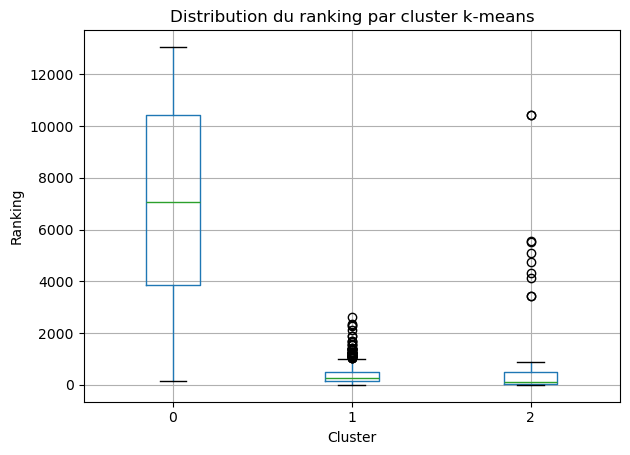

In [9]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_kmeans')
plt.title("Distribution du ranking par cluster k-means")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [10]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Modèle : ranking ~ cluster (traité comme facteur)
model = ols('ranking ~ C(cluster_kmeans)', data=data_clust).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                         sum_sq       df            F  PR(>F)
C(cluster_kmeans)  6.579443e+10      2.0  2380.154309     0.0
Residual           5.406818e+11  39119.0          NaN     NaN


In [11]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
# Variance des centres par variable
importance = centers.var(axis=0)  # variance sur les lignes (clusters)

importance_sorted = importance.sort_values(ascending=False)
importance_sorted.to_csv("../OUTPUTS/Var_kmeans_importance_all.csv")
print(importance_sorted)

guid_count_publications_a-2    233.027335
guid_sum_Impact_factor_a-2     233.027335
guid_sum_author_a-2            204.173292
guid_count_Author_a-2          204.173292
cong_count_speaker_a-2          20.908418
                                  ...    
cong_count_poster                0.361676
guid_count_First_Author_a-1      0.016007
guid_sum_first_author_a-1        0.015145
guid_count_First_Author          0.010804
guid_sum_first_author            0.009919
Length: 69, dtype: float64


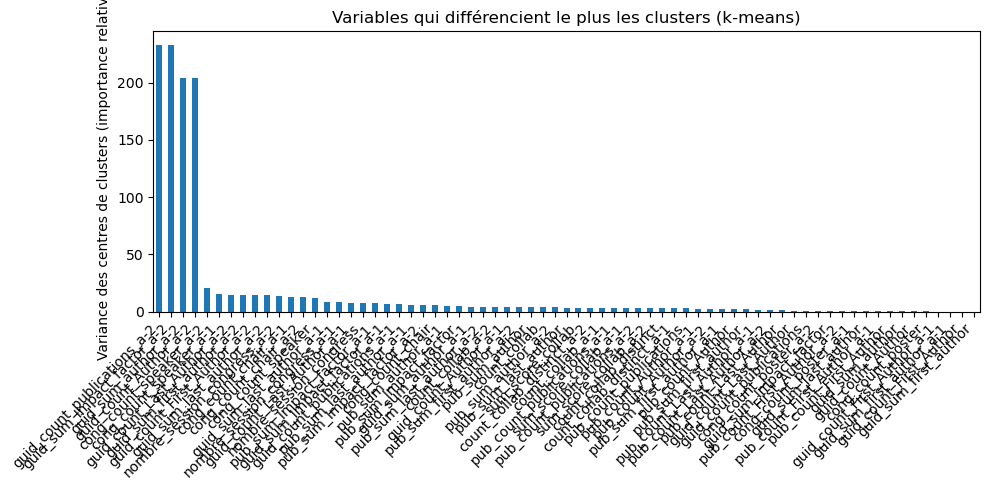

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
importance_sorted.plot(kind='bar')
plt.ylabel("Variance des centres de clusters (importance relative)")
plt.title("Variables qui différencient le plus les clusters (k-means)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Clustering hierarchique

Avec le clustering hiérarchique, le nombre de clusters k s'optimise en regardant le dendogramme. 

Dans le dendogramme plus bas, le nombre k idéal semble être à 2. Or avec 2, il n'y a pas de moyen pour différencier les RS des KOL.

Il est également important de noter que certains individus qui ont été identifiés comme étant des RS par les experts sont dans le groupe Other.

A mon avis, il faudrait faire du clustering sur les évolutions/delta (différences des ranking par exemple).

In [13]:
from sklearn.cluster import AgglomerativeClustering

# Choisis le nombre de clusters, par ex. 4
hclust = AgglomerativeClustering(n_clusters=3, linkage='ward')
hclust_labels = hclust.fit_predict(X_scaled)

data_clust['cluster_hier'] = hclust_labels

print(data_clust[['cluster_hier']].head())
print(data_clust['cluster_hier'].value_counts())

   cluster_hier
0             1
1             1
2             1
3             1
4             1
cluster_hier
1    38460
0      643
2       19
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

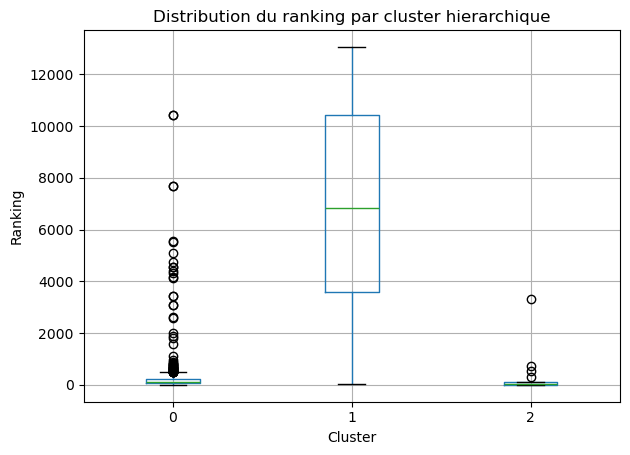

In [14]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_hier')
plt.title("Distribution du ranking par cluster hierarchique")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [15]:
# Mapping pour cluster_kmeans
mapping_kmeans = {
    0: "Other",
    1: "RS",
    2: "KOL"
}

# Mapping pour cluster_hier
mapping_hier = {
    0: "RS",
    1: "Other",
    2: "KOL"
}

data_clust["cluster_kmeans"] = data_clust["cluster_kmeans"].replace(mapping_kmeans)
data_clust["cluster_hier"]   = data_clust["cluster_hier"].replace(mapping_hier)

In [16]:
ct = pd.crosstab(data_clust['cluster_kmeans'],
                 data_clust['cluster_hier'])
print(ct)

cluster_hier    KOL  Other   RS
cluster_kmeans                 
KOL               5      0   44
Other             3  37578   18
RS               11    882  581


In [17]:
data_clust = data_clust.merge(
    data[['entity_annee','entity','annee']],   # on ne garde que ce qui est utile
    on='entity_annee',
    how='left'                          # on garde toutes les lignes de data_clust
)
data_clust.head(10)

,entity_annee,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,guid_count_publications,...,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2,cluster_kmeans,ranking,cluster_hier,entity,annee
0,A N Gratchev_2023,2,0.2,0,0.0,0,0.0,2,0.2,0,...,0,0,0,0,0.000000,Other,8735,Other,A N Gratchev,2023-01-01
1,A N Gratchev_2024,1,0.1,0,0.0,0,0.0,1,0.1,0,...,0,0,3,3,0.076447,Other,8223,Other,A N Gratchev,2024-01-01
2,A N Gratchev_2025,1,0.1,0,0.0,0,0.0,1,0.1,0,...,0,0,3,6,0.129972,Other,5888,Other,A N Gratchev,2025-01-01
3,Aadel A Chaudhuri_2023,2,6.9,0,0.0,0,0.0,2,6.9,0,...,0,0,0,0,0.000000,Other,1935,Other,Aadel A Chaudhuri,2023-01-01
4,Aadel A Chaudhuri_2024,3,0.3,1,0.1,0,0.0,2,0.2,0,...,0,1,53,67,4.834006,Other,2155,Other,Aadel A Chaudhuri,2024-01-01
5,Aadel A Chaudhuri_2025,2,29.8,1,29.7,0,0.0,1,0.1,0,...,0,0,7,14,1.064320,Other,2307,Other,Aadel A Chaudhuri,2025-01-01
6,Aakash Desai_2023,5,20.1,1,4.0,4,16.1,0,0.0,0,...,0,0,3,3,0.745592,RS,285,Other,Aakash Desai,2023-01-01
7,Aakash Desai_2024,7,22.2,3,8.0,3,14.1,1,0.1,0,...,2,1,110,112,9.115923,RS,300,RS,Aakash Desai,2024-01-01
8,Aakash Desai_2025,12,83.3,8,54.5,2,13.8,2,15.0,0,...,1,1,354,366,29.269657,RS,309,Other,Aakash Desai,2025-01-01
9,Aaron Allen_2023,2,8.7,2,8.7,0,0.0,0,0.0,0,...,0,0,3,3,0.686332,Other,9893,Other,Aaron Allen,2023-01-01


In [18]:
data_clust.to_csv("../OUTPUTS/Res_clust_all.csv", index=False)

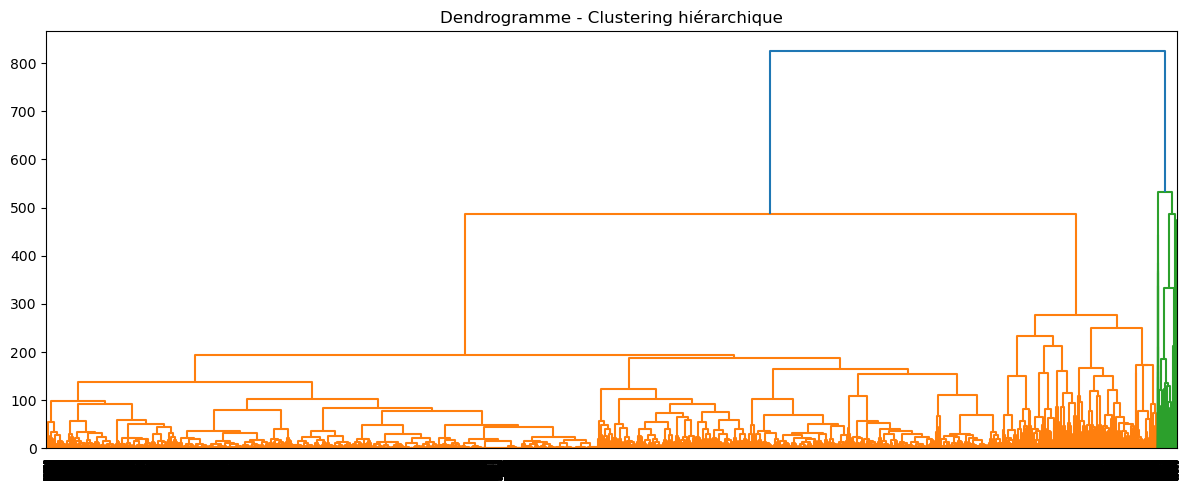

In [19]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Matrice de liaison
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=data_clust.index.to_list(), leaf_rotation=90)
plt.title("Dendrogramme - Clustering hiérarchique")
plt.tight_layout()
plt.show()

Le code ci-dessous permet d'identifier les noms (entity_annee) présents dans chaque feuille du dendogramme. Cela revient finalement aux clusters que nous avons obtenus avec la fonction AgglomerativeClustering

In [28]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Choix : nombre de clusters
k = 3  # par exemple

cluster_labels = fcluster(Z, t=k, criterion='maxclust')

In [29]:
cluster_labels

array([1, 1, 1, ..., 1, 1, 1], shape=(39122,), dtype=int32)

In [30]:
data_clust["cluster_hier_dend"] = cluster_labels

In [31]:
clusters_dict = (
    data_clust
    .groupby("cluster_hier_dend")["entity_annee"]
    .apply(list)
    .to_dict()
)

In [33]:
counts_dict = {cluster_id: len(entities)
               for cluster_id, entities in clusters_dict.items()}

print(counts_dict)

{1: 38460, 2: 19, 3: 643}
